<a href="https://colab.research.google.com/github/webgioant/Flask-Tree-Analysis/blob/main/P5_Autokorelasi_spasial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ACARA 5
#Auto Korelasi Data Spatial

In [ ]:
!pip install seaborn
!pip install pandas
!pip install esda
!pip install pysal
!pip install splot
!pip install geopandas
!pip install numpy
!pip install contextily
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 10.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 882.2/882.2 kB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.9/47.9 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.6/141.6 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.1/248.1 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.9/389.9 kB 30.7 MB/s eta 0:00:00
   ━━━━

In [ ]:
import seaborn as sns
import pandas as pd
import esda
from pysal.lib import weights
from splot.esda import (
    moran_scatterplot, lisa_cluster,
plot_local_autocorrelation, plot_moran
)
from splot.libpysal import plot_spatial_weights
import geopandas as gpd
import numpy as np
import contextily as ctx
import matplotlib.pyplot as plt

In [ ]:
%cd /content/drive/MyDrive/Colab Notebooks/SAINS DATA SPASIAL

/content/drive/MyDrive/Colab Notebooks/SAINS DATA SPASIAL


**3) Menampilkan informasi yang ada di dalam data yang sudah dipanggil**

In [ ]:
# Read the file in
br = gpd.read_file("/content/drive/MyDrive/Colab Notebooks/SAINS DATA SPASIAL/kontur_boundaries_ID_20230628.gpkg")
br.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [ ]:
# Index table on the LAD ID
br = br.set_index("lad16cd", drop=False)
# Display summary
br.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 380 entries, E06000001 to W06000024
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   objectid   380 non-null    int64   
 1   lad16cd    380 non-null    object  
 2   lad16nm    380 non-null    object  
 3   Pct_Leave  380 non-null    float64 
 4   geometry   380 non-null    geometry
dtypes: float64(1), geometry(1), int64(1), object(2)
memory usage: 17.8+ KB


**4) Mempersiapkan kebutuhan data yang nanti akan dilakukan proses auto korelasi
seperti membuat plot polygon sampai memberikan bobot pada data tersebut **

<timed exec>:1: FutureWarning: `idVariable` is deprecated and will be removed in future. Use `ids` instead.


CPU times: user 2.64 s, sys: 150 ms, total: 2.79 s
Wall time: 2.79 s


/usr/local/lib/python3.11/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 6 islands with ids: E06000046, E06000053, S12000013, S12000023, S12000027, W06000001.
  W.__init__(self, neighbors, ids=ids, **kw)


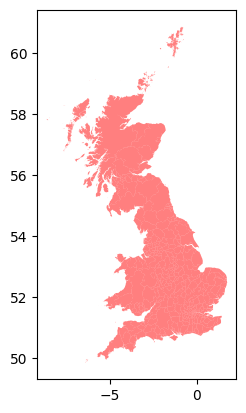

In [ ]:
# Plot polygons
ax = br.plot(alpha=0.5, color='red');

# Create the spatial weights matrix
%time w = weights.Queen.from_dataframe(br,idVariable="lad16cd")

**5) Menampilkan hasil dari pembobotan dalam bentuk plotingan**

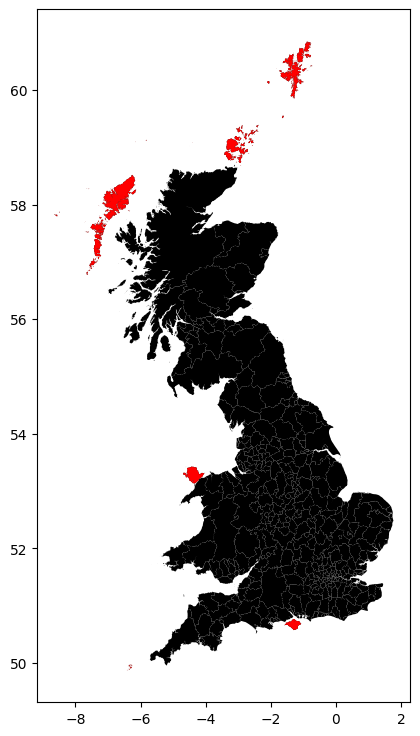

In [ ]:
w['E08000012']

ax = br.plot(color='k', figsize=(9, 9))
br.loc[w.islands, :].plot(color='red', ax=ax);

**6) Menampilkan pembobotan data spasial dalam bentuk garis hubung pada tiap titik **

In [ ]:
br = br.drop(w.islands)
# Create the spatial weights matrix
# NOTE: this might take a few minutes as the geometries are
#       are very detailed
%time w = weights.Queen.from_dataframe(br, idVariable="lad16cd")

# Row standardize the matrix
w.transform = 'R'

w['E08000012']

<timed exec>:1: FutureWarning: `idVariable` is deprecated and will be removed in future. Use `ids` instead.


CPU times: user 2.52 s, sys: 82.1 ms, total: 2.6 s
Wall time: 2.68 s


{'E08000014': 0.3333333333333333,
 'E06000006': 0.3333333333333333,
 'E08000011': 0.3333333333333333}

27700

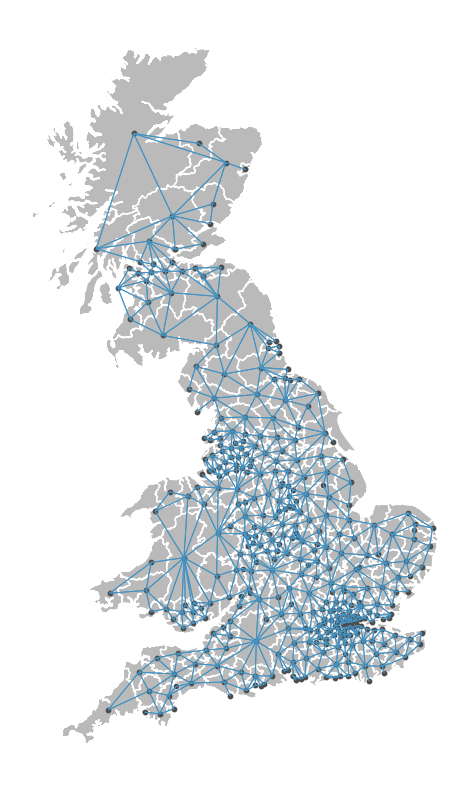

In [ ]:
plot_spatial_weights(w, br.to_crs(epsg=27700),
indexed_on="lad16cd"); # Use the British National Grid,
27700


**7) Melakukan computing terhadap data spatial agar bisa dilakukan korelasi antara dua
buah data**

In [ ]:
br['w_Pct_Leave'] = weights.lag_spatial(w, br['Pct_Leave'])
br[['lad16cd', 'Pct_Leave', 'w_Pct_Leave']].head()

,lad16cd,Pct_Leave,w_Pct_Leave
lad16cd,,,
E06000001,E06000001,69.57,59.640000
E06000002,E06000002,65.48,60.526667
E06000003,E06000003,66.19,60.376667
E06000004,E06000004,61.73,60.488000
E06000005,E06000005,56.18,57.430000


In [ ]:
w.neighbors['E06000001']

['E06000047', 'E06000004']

In [ ]:
neis = br.loc[w.neighbors['E06000001'], 'Pct_Leave']
neis


,Pct_Leave
lad16cd,
E06000047,57.55
E06000004,61.73


In [ ]:
neis.mean()

np.float64(59.64)

In [ ]:
br['Pct_Leave_std'] = (
br['Pct_Leave'] - br['Pct_Leave'].mean()
) / br['Pct_Leave'].std()
br['w_Pct_Leave_std'] = weights.lag_spatial(w,
br['Pct_Leave_std'])

**8) Moran plot, memvisualisasikan dataset yang sudah dilakukan proses autokorelasi
antara dua buah data spatial, sehingga dari bisa memperhitungan seberapa Tingkat
korelasi tersebut**

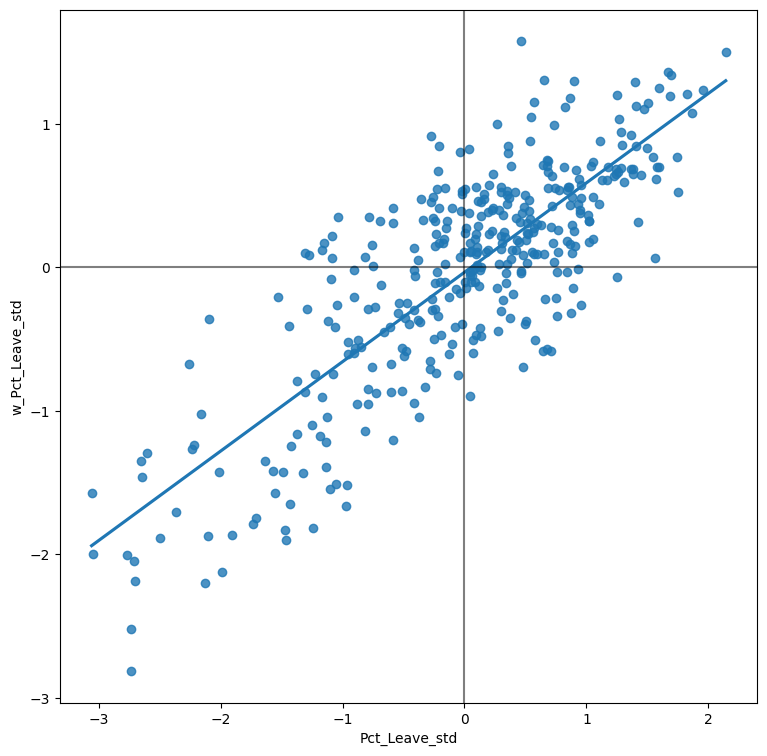

In [ ]:
# Setup the figure and axis
f, ax = plt.subplots(1, figsize=(9, 9))
# Plot values
sns.regplot(x='Pct_Leave_std', y='w_Pct_Leave_std', data=br,
ci=None)
# Add vertical and horizontal lines
plt.axvline(0, c='k', alpha=0.5)
plt.axhline(0, c='k', alpha=0.5)
# Display
plt.show()


# Tugas Praktikum

**1) Buatlah tampilan korelasi dua buah data menggunakan hasil kolom w_Pct_Leave **

In [ ]:
br['w_Pct_Leave'] = weights.lag_spatial(w, br['Pct_Leave'])
br[['lad16cd', 'Pct_Leave', 'w_Pct_Leave']].head()

,lad16cd,Pct_Leave,w_Pct_Leave
lad16cd,,,
E06000001,E06000001,69.57,59.640000
E06000002,E06000002,65.48,60.526667
E06000003,E06000003,66.19,60.376667
E06000004,E06000004,61.73,60.488000
E06000005,E06000005,56.18,57.430000


In [ ]:
w.neighbors['E06000001']

['E06000047', 'E06000004']

In [ ]:
neis_5 = br.loc[w.neighbors['E06000001'], 'w_Pct_Leave']
neis_5

,w_Pct_Leave
lad16cd,
E06000047,58.735
E06000004,60.488


In [ ]:
# Calculate the mean of the Pct_Leave for the neighbors
neis_5.mean()

np.float64(59.6115)

In [ ]:
br['w_Pct_Leave_std'] = (
br['w_Pct_Leave'] - br['w_Pct_Leave'].mean()
) / br['w_Pct_Leave'].std()
br['Pct_Leave_std'] = weights.lag_spatial(w,
br['w_Pct_Leave'])

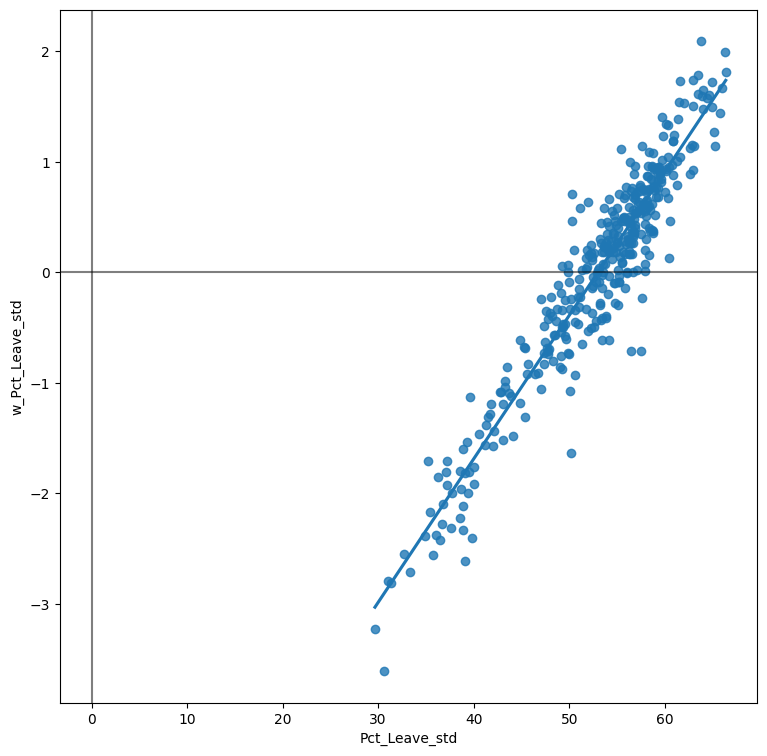

In [ ]:
# Setup the figure and axis
f, ax = plt.subplots(1, figsize=(9, 9))
# Plot values
sns.regplot(x='Pct_Leave_std', y='w_Pct_Leave_std', data=br,
ci=None)
# Add vertical and horizontal lines
plt.axvline(0, c='k', alpha=0.5)
plt.axhline(0, c='k', alpha=0.5)
# Display
plt.show()

**2) Carilah data dengan ekstensi gpkg dan tampilan korelasi data – data tersebut**

In [ ]:
# Read the file in
br = gpd.read_file("/content/drive/MyDrive/Colab Notebooks/SAINS DATA SPASIAL/unit06_spatialclustering/unit06_spatialclustering/files/london_abb.gpkg")
br.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<timed exec>:1: FutureWarning: `idVariable` is deprecated and will be removed in future. Use `ids` instead.


CPU times: user 1.47 s, sys: 4.72 ms, total: 1.47 s
Wall time: 1.53 s


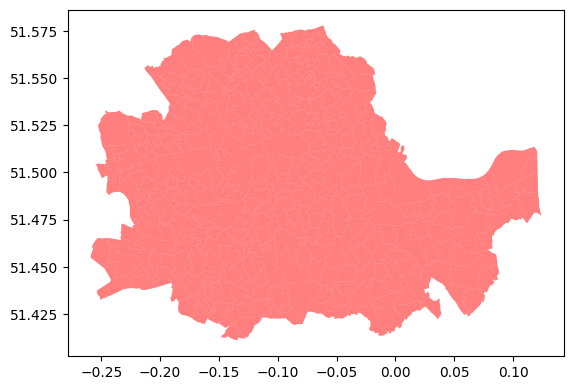

In [ ]:
# Plot polygons
ax = br.plot(alpha=0.5, color='red');

# Create the spatial weights matrix
%time w = weights.Queen.from_dataframe(br,idVariable="MSOA_CODE")

In [ ]:
# Accessing the first key as an example
first_key = list(w.neighbors.keys())[9]
w[first_key]

# The plotting part might not be relevant for this data, you can uncomment and adapt if needed
# ax = br.plot(color='k', figsize=(9, 9))
# br.loc[w.islands, :].plot(color='red', ax=ax);

{'E02000184': 0.14285714285714285,
 'E02000561': 0.14285714285714285,
 'E02000563': 0.14285714285714285,
 'E02000172': 0.14285714285714285,
 'E02000568': 0.14285714285714285,
 'E02000180': 0.14285714285714285,
 'E02000168': 0.14285714285714285}

In [ ]:
if w:
    # Accessing the first key as an example
    first_key = list(w.neighbors.keys())[0]
    print(w[first_key])

    # The plotting part might not be relevant for this data, you can uncomment and adapt if needed
    # ax = br.plot(color='k', figsize=(9, 9))
    # br.loc[w.islands, :].plot(color='red', ax=ax);
else:
    print("The spatial weights matrix 'w' has not been created. Please run the cell that creates the weights matrix first.")

{'E02000884': 0.07692307692307693, 'E02000808': 0.07692307692307693, 'E02000809': 0.07692307692307693, 'E02000618': 0.07692307692307693, 'E02000575': 0.07692307692307693, 'E02000889': 0.07692307692307693, 'E02000977': 0.07692307692307693, 'E02000890': 0.07692307692307693, 'E02000371': 0.07692307692307693, 'E02000192': 0.07692307692307693, 'E02000193': 0.07692307692307693, 'E02000576': 0.07692307692307693, 'E02000878': 0.07692307692307693}


In [ ]:
br = br.drop(w.islands)
# Create the spatial weights matrix
# NOTE: this might take a few minutes as the geometries are
#       are very detailed
%time w = weights.Queen.from_dataframe(br, idVariable="MSOA_CODE")

# Row standardize the matrix
w.transform = 'R'

w['E02000168']

<timed exec>:1: FutureWarning: `idVariable` is deprecated and will be removed in future. Use `ids` instead.


CPU times: user 1.82 s, sys: 12.6 ms, total: 1.84 s
Wall time: 2.12 s


{'E02000561': 0.2,
 'E02000174': 0.2,
 'E02000172': 0.2,
 'E02000166': 0.2,
 'E02000557': 0.2}

27700

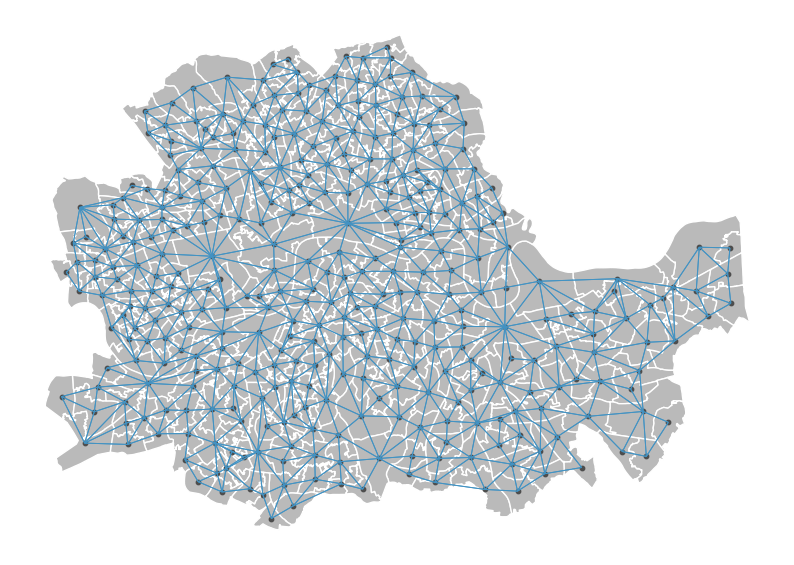

In [ ]:
plot_spatial_weights(w, br.to_crs(epsg=27700),
indexed_on="MSOA_CODE"); # Use the British National Grid,
27700

In [ ]:
# Index table on the MSOA CODE
br = br.set_index("MSOA_CODE", drop=False)
# Display summary
br.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 353 entries, 1.3196650421857623 to 1.4337173963960774
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   MSOA_CODE                    353 non-null    float64 
 1   accommodates                 353 non-null    float64 
 2   bathrooms                    353 non-null    float64 
 3   bedrooms                     353 non-null    float64 
 4   beds                         353 non-null    float64 
 5   number_of_reviews            353 non-null    float64 
 6   reviews_per_month            353 non-null    float64 
 7   review_scores_rating         353 non-null    float64 
 8   review_scores_accuracy       353 non-null    float64 
 9   review_scores_cleanliness    353 non-null    float64 
 10  review_scores_checkin        353 non-null    float64 
 11  review_scores_communication  353 non-null    float64 
 12  review_scores_location       

In [ ]:
br['accommodates'] = weights.lag_spatial(w, br['bedrooms'])
br[['GSS_CODE', 'bedrooms', 'accommodates']].head(9)

,GSS_CODE,bedrooms,accommodates
MSOA_CODE,,,
1.319665,E09000001,1.201299,1.319665
1.510292,E09000007,1.725275,1.510292
1.588276,E09000007,1.688000,1.588276
1.517693,E09000007,1.804196,1.517693
1.498870,E09000007,1.679612,1.498870
1.480605,E09000007,1.467890,1.480605
1.480147,E09000007,1.540323,1.480147
1.549314,E09000007,1.289773,1.549314
1.514389,E09000007,1.407895,1.514389


In [ ]:
print(br.columns)

Index(['MSOA_CODE', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
       'number_of_reviews', 'reviews_per_month', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'property_count',
       'BOROUGH', 'GSS_CODE', 'geometry'],
      dtype='object')


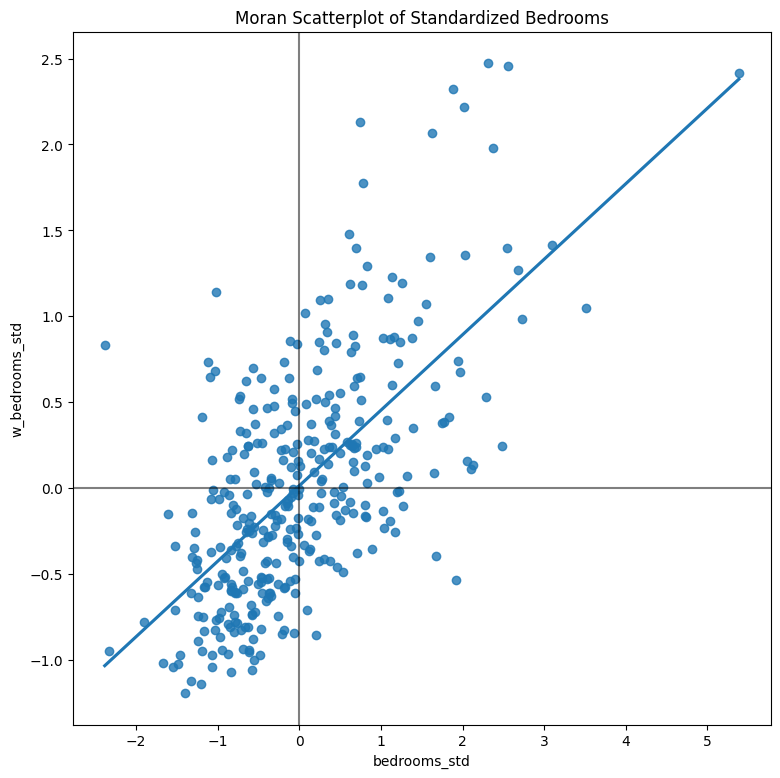

In [ ]:
# Setup the figure and axis
f, ax = plt.subplots(1, figsize=(9, 9))
# Plot values
sns.regplot(x='bedrooms_std', y='w_bedrooms_std', data=br, ci=None)
# Add vertical and horizontal lines
plt.axvline(0, c='k', alpha=0.5)
plt.axhline(0, c='k', alpha=0.5)
# Display
plt.title('Moran Scatterplot of Standardized Bedrooms')
plt.show()